# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [4]:
# TODO 1: choropleth of total_gdp
fig_total = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Total GDP by Country, 2007 (count-like aggregate)"
)
fig_total.show()

# TODO 2: choropleth of gdpPercap
fig_rate = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="GDP per Capita by Country, 2007 (rate)"
)
fig_rate.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp", "gdpPercap"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "total_gdp", "gdpPercap"]]

print("Top 5 by total GDP:\n", top_total.to_string(index=False))
print("\nTop 5 by GDP per capita:\n", top_rate.to_string(index=False))


Top 5 by total GDP:
       country    total_gdp    gdpPercap
United States 1.293446e+13 42951.653090
        China 6.539501e+12  4959.114854
        Japan 4.035135e+12 31656.068060
        India 2.722925e+12  2452.210407
      Germany 2.650871e+12 32170.374420

Top 5 by GDP per capita:
       country    total_gdp   gdpPercap
       Norway 2.284214e+11 49357.19017
       Kuwait 1.185305e+11 47306.98978
    Singapore 2.146433e+11 47143.17964
United States 1.293446e+13 42951.65309
      Ireland 1.671412e+11 40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ The top-5 lists are substantially different. Total GDP is led by the United States, China, Japan, India, and Germany, while GDP per capita is led by Norway, Kuwait, Singapore, the United States, and Ireland. I would show the GDP-per-capita (rate) map because it reduces the population-size effect and is a more appropriate way to communicate prosperity per person rather than economic size alone.


## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

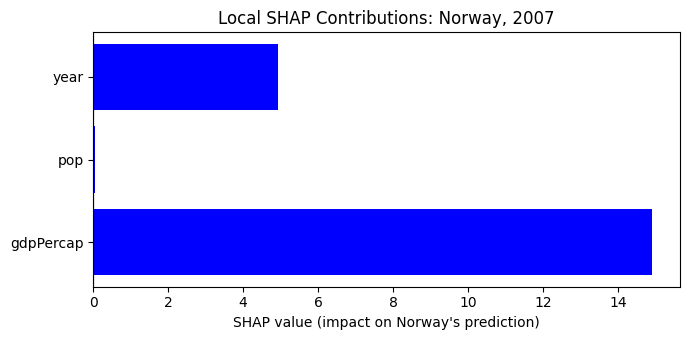

Norway 2007 SHAP contributions:
gdpPercap    14.915377
pop           0.050255
year          4.931463


In [5]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder["country"] == "Norway") & (gapminder["year"] == 2007)].index[0]
vals = np.asarray(shap_values)[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
features = ["gdpPercap", "pop", "year"]
bar_colors = ["blue" if v >= 0 else "red" for v in vals]
ax.barh(features, vals, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (impact on Norway's prediction)")
ax.set_title("Local SHAP Contributions: Norway, 2007")
plt.tight_layout()
plt.show()

print("Norway 2007 SHAP contributions:")
print(pd.Series(vals, index=features).to_string())


**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ For Norway in 2007, gdpPercap contributed the most positively, followed by year and then pop; none of the three SHAP contributions is negative for this particular prediction. Global feature importance can tell us which features matter most across the whole model, but it does not tell us the signed contribution for Norway specifically. Therefore, the local SHAP explanation is the appropriate answer to the director's country-specific question.


## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

Africa: mean=54.81, 95% CI=(52.15, 57.44)
Europe: mean=77.65, 95% CI=(76.57, 78.65)


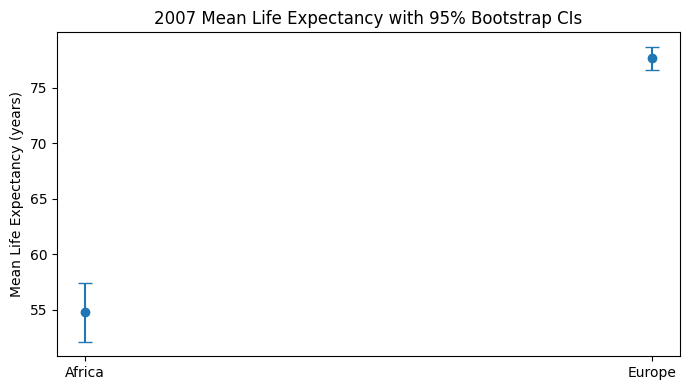

In [6]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = [
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ]
    return (
        np.mean(values),
        np.percentile(boot_means, 2.5),
        np.percentile(boot_means, 97.5)
    )

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=({result_a[1]:.2f}, {result_a[2]:.2f})")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=({result_b[1]:.2f}, {result_b[2]:.2f})")

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
lower_errors = [result_a[0] - result_a[1], result_b[0] - result_b[1]]
upper_errors = [result_a[2] - result_a[0], result_b[2] - result_b[0]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=5
)
ax.set_ylabel("Mean Life Expectancy (years)")
ax.set_title("2007 Mean Life Expectancy with 95% Bootstrap CIs")
plt.tight_layout()
plt.show()


**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has the wider confidence interval. In this dataset, Africa has 52 countries compared with 30 in Europe, so the wider interval is not caused by a smaller sample size. Africa also has much higher variation in life expectancy (sample SD about 9.63 years versus about 2.98 years for Europe), so the main reason for the wider CI is the higher variation among countries.


## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

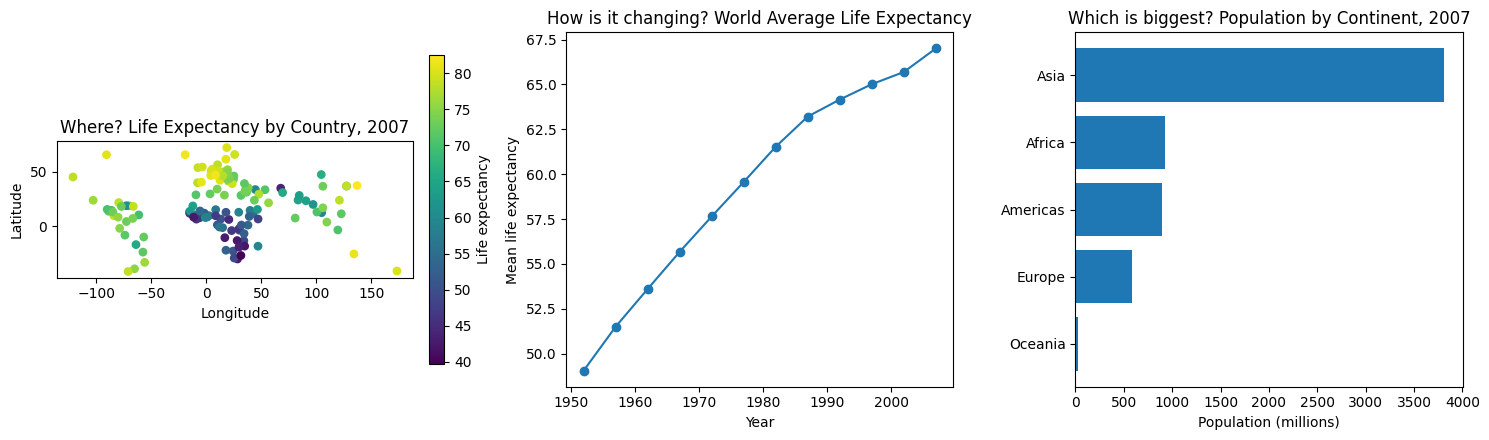

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
sc = axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    cmap="viridis",
    s=28
)
axes[0].set_title("Where? Life Expectancy by Country, 2007")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[0], fraction=0.04, pad=0.04, label="Life expectancy")

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year", as_index=False)["lifeExp"].mean()
axes[1].plot(world_trend["year"], world_trend["lifeExp"], marker="o")
axes[1].set_title("How is it changing? World Average Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean life expectancy")

# TODO 3: population by continent bar chart (axes[2])
continent_pop = (
    gapminder[gapminder["year"] == 2007]
    .groupby("continent")["pop"]
    .sum()
    .sort_values()
)
axes[2].barh(continent_pop.index, continent_pop.values / 1e6)
axes[2].set_title("Which is biggest? Population by Continent, 2007")
axes[2].set_xlabel("Population (millions)")

plt.tight_layout()
plt.show()


**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I would keep the world-average life-expectancy trend line. It is the fastest panel to read and directly answers the monitoring question, “How is the overall situation changing over time?” It is especially useful for spotting broad trends or changes that deserve further investigation.


**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I would standardize on rate-based maps such as GDP per capita when the reporting question is about prosperity or comparable outcomes, because raw counts can be dominated by population size. For a journalist asking about a specific country, I would lead with local feature importance such as SHAP, because global importance describes the model overall while local importance explains one prediction and its direction. I would keep the dashboard focused on complementary views: location, trend, and continental population ranking. The world-average life-expectancy estimate should not be presented as a bare point estimate when it is used for inference, because uncertainty affects how confidently changes and comparisons should be interpreted. Overall, the dashboard should communicate both the signal and the uncertainty behind it.
